In [ ]:
import pandas as pd
import numpy as np
import os

# Step 1 — Define the targets

# ── Load raw data ───
dataset_path = "/content/dataset.csv"

if not os.path.exists(dataset_path):
    raise FileNotFoundError(
        f"Missing {dataset_path}. Please upload the `dataset.csv` file "
        "to the Colab environment (e.g., drag and drop into the files tab on the left)."
    )

df = pd.read_csv(dataset_path)

print(f"Rows: {len(df)}  |  Columns: {list(df.columns)}\n")

# ── Verify the Revenue formula (the key finding that drives Step 1) ─
calculated_revenue = df["Quantity"] * df["Unit_Price"]
max_diff = (calculated_revenue - df["Revenue"]).abs().max()

print("Revenue formula check")
print(f"  max |Quantity * Unit_Price - Revenue| = {max_diff:.10f}")
if max_diff < 1e-6:
    print("  -> CONFIRMED: Revenue = Quantity * Unit_Price (deterministic formula)")
elif max_diff < 1e-2: # Allow for minor floating point differences
    print("  -> NEARLY CONFIRMED: Revenue = Quantity * Unit_Price (very close,likely floating point diffs)")
else:
    print("  -> NOT a pure formula — Revenue may be independently learnable")

# ── Define target A: Revenue ───
# Quantity and Unit_Price are EXCLUDED from inputs — otherwise the model
# just learns multiplication instead of a genuine pattern.
TARGET_REVENUE = "Revenue"
FEATURES_REVENUE = [
    "Category", "Sub_Category", "Product_Name", "Region",
    "Order_Date",  # will be decomposed into Year/Month/Quarter in Step 3
]

# ── Define target B: Profit ───
# All other columns are fair game — Profit margin is not a fixed
# function of Quantity, Unit_Price, or Revenue.
TARGET_PROFIT = "Profit"
FEATURES_PROFIT = [
    "Category", "Sub_Category", "Product_Name", "Region",
    "Quantity", "Unit_Price", "Revenue", "Order_Date",
]

# ── Columns dropped for both targets, and why ────────────────────────
DROP_ALWAYS = {
    "Order_ID":      "pure row identifier, no predictive signal",
    "Customer_Name": "9,371 unique values out of 10,000 rows — near-unique, can't generalize",
    "Country":       "single constant value — zero variance",
}

print("\nColumns dropped for every model:")
for col, reason in DROP_ALWAYS.items():
    print(f"  {col:<15} -> {reason}")

print(f"\nTarget A: {TARGET_REVENUE}")
print(f"  Inputs ({len(FEATURES_REVENUE)}): {FEATURES_REVENUE}")
print(f"  Quantity/Unit_Price excluded on purpose (formula leakage)")

print(f"\nTarget B: {TARGET_PROFIT}")
print(f"  Inputs ({len(FEATURES_PROFIT)}): {FEATURES_PROFIT}")

# ── Save the two problem specs so later steps can just import them ──
problem_spec = {
    "revenue": {"target": TARGET_REVENUE, "features": FEATURES_REVENUE},
    "profit":  {"target": TARGET_PROFIT,  "features": FEATURES_PROFIT},
    "drop_always": list(DROP_ALWAYS.keys()),
}

import json
with open("step1_problem_spec.json", "w") as f:
    json.dump(problem_spec, f, indent=2)

print("\nSaved problem spec -> step1_problem_spec.json")

Rows: 10000  |  Columns: ['Order_ID', 'Order_Date', 'Customer_Name', 'City', 'State', 'Region', 'Country', 'Category', 'Sub_Category', 'Product_Name', 'Quantity', 'Unit_Price', 'Revenue', 'Profit']

Revenue formula check
  max |Quantity * Unit_Price - Revenue| = 0.0000000000
  -> CONFIRMED: Revenue = Quantity * Unit_Price (deterministic formula)

Columns dropped for every model:
  Order_ID        -> pure row identifier, no predictive signal
  Customer_Name   -> 9,371 unique values out of 10,000 rows — near-unique, can't generalize
  Country         -> single constant value — zero variance

Target A: Revenue
  Inputs (5): ['Category', 'Sub_Category', 'Product_Name', 'Region', 'Order_Date']
  Quantity/Unit_Price excluded on purpose (formula leakage)

Target B: Profit
  Inputs (8): ['Category', 'Sub_Category', 'Product_Name', 'Region', 'Quantity', 'Unit_Price', 'Revenue', 'Order_Date']

Saved problem spec -> step1_problem_spec.json


In [ ]:
"""
Step 2 — Clean the data

Goal: turn the raw CSV into a dataframe that's safe to build features on.

Three jobs:
  1. Parse Order_Date, which mixes two formats: MM-DD-YY and MM-DD-YYYY
  2. Drop columns identified in Step 1 as noise (ID, near-unique, zero-variance)
  3. Re-validate for missing values / duplicates after the above
"""

import pandas as pd
import numpy as np
import json

# ── Load raw data ───────────────────────────────────────────────────
df = pd.read_csv("dataset.csv")
n_start = len(df)
print(f"Loaded {n_start} rows, {df.shape[1]} columns")

# ── Load Step 1's decisions so this script stays consistent ─────────
with open("step1_problem_spec.json") as f:
    spec = json.load(f)
drop_always = spec["drop_always"]

# ── Job 1: parse Order_Date, handling both mixed formats ────────────
def parse_mixed_date(value: str):
    """
    Order_Date contains two formats in the same column:
       MM-DD-YY   e.g. 08-23-23   (2-digit year)
       MM-DD-YYYY e.g. 07-11-2024 (4-digit year)
    Decide the format by the length of the last token, then parse
    explicitly rather than letting pandas guess (guessing silently
    mis-parses ambiguous 2-digit years).
    """
    value = str(value)
    year_token = value.split("-")[-1]
    try:
        if len(year_token) == 4:
            return pd.to_datetime(value, format="%m-%d-%Y")
        else:
            return pd.to_datetime(value, format="%m-%d-%y")
    except ValueError:
        return pd.NaT

df["Order_Date"] = df["Order_Date"].apply(parse_mixed_date)

n_failed = df["Order_Date"].isna().sum()
print(f"\nDate parsing: {n_failed} rows failed to parse "
      f"({n_failed/n_start:.2%} of data)")
print(f"Date range: {df['Order_Date'].min()} to {df['Order_Date'].max()}")

# Drop any rows where the date failed to parse — a malformed date
# can't be used for the seasonal features built in Step 3.
if n_failed > 0:
    df = df.dropna(subset=["Order_Date"])
    print(f"Dropped {n_failed} rows with unparseable dates")

# ── Job 2: drop noise columns identified in Step 1 ───────────────────
existing_drops = [c for c in drop_always if c in df.columns]
df = df.drop(columns=existing_drops)
print(f"\nDropped columns: {existing_drops}")
print(f"Remaining columns ({df.shape[1]}): {list(df.columns)}")

# ── Job 3: re-validate after cleaning ────────────────────────────────
print("\nPost-cleaning validation")
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print(" No missing values.")
else:
    print(" Missing values found:")
    print(missing.to_string())

n_dupes = df.duplicated().sum()
print(f"  Duplicate rows: {n_dupes}")

print(f"\nFinal shape: {df.shape}  (started at {n_start} rows)")

# ── Save cleaned data for Step 3 onward ──────────────────────────────
df.to_csv("step2_cleaned.csv", index=False)
print("\nSaved cleaned data -> step2_cleaned.csv")

Loaded 10000 rows, 14 columns

Date parsing: 0 rows failed to parse (0.00% of data)
Date range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00

Dropped columns: ['Order_ID', 'Customer_Name', 'Country']
Remaining columns (11): ['Order_Date', 'City', 'State', 'Region', 'Category', 'Sub_Category', 'Product_Name', 'Quantity', 'Unit_Price', 'Revenue', 'Profit']

Post-cleaning validation
 No missing values.
  Duplicate rows: 0

Final shape: (10000, 11)  (started at 10000 rows)

Saved cleaned data -> step2_cleaned.csv


In [ ]:
"""
Step 3 — Engineer features

Goal: turn the cleaned dataframe into one with features a model can
actually learn from.

Two jobs:
  1. Decompose Order_Date into Year, Month, Quarter, DayOfWeek, IsWeekend
  2. Finalize the geographic feature: keep Region, drop City/State
     (108 and 47 unique values — too high-cardinality relative to
     10,000 rows, and Region already captures most of the signal)
"""

import pandas as pd
import numpy as np

# ── Load Step 2's cleaned data ───────────────────────────────────────
df = pd.read_csv("step2_cleaned.csv")
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
print(f"Loaded {len(df)} rows, {df.shape[1]} columns")

# ── Job 1: decompose the date into model-usable parts ────────────────
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Quarter"] = df["Order_Date"].dt.quarter
df["DayOfWeek"] = df["Order_Date"].dt.dayofweek       # 0 = Monday
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

print("\nDate features created: Year, Month, Quarter, DayOfWeek, IsWeekend")
print(df[["Order_Date", "Year", "Month", "Quarter", "DayOfWeek", "IsWeekend"]].head(3))

# ── Job 2: finalize geographic feature — Region only ──────────────────
geo_cardinality = {
    "City":   df["City"].nunique(),
    "State":  df["State"].nunique(),
    "Region": df["Region"].nunique(),
}
print("\nGeographic column cardinality:")
for col, n in geo_cardinality.items():
    print(f"  {col:<8} {n} unique values")

# City/State are dropped: too many categories relative to row count —
# one-hot encoding them would create 100+ sparse columns, and many
# individual cities have too few rows to learn a reliable pattern.
df = df.drop(columns=["City", "State"])
print("\nDropped: City, State (kept Region as the geographic feature)")

# ── Sanity check: cardinality of remaining categoricals ───────────────
print("\nRemaining categorical cardinality (for Step 6 encoding decisions):")
for col in ["Category", "Sub_Category", "Product_Name", "Region"]:
    print(f"  {col:<15} {df[col].nunique()} unique values")

# ── Save engineered data for Step 4 onward ────────────────────────────
df.to_csv("step3_engineered.csv", index=False)
print(f"\nFinal shape: {df.shape}")
print("Saved engineered data -> step3_engineered.csv")

Loaded 10000 rows, 11 columns

Date features created: Year, Month, Quarter, DayOfWeek, IsWeekend
  Order_Date  Year  Month  Quarter  DayOfWeek  IsWeekend
0 2023-08-23  2023      8        3          2          0
1 2024-12-20  2024     12        4          4          0
2 2024-01-29  2024      1        1          0          0

Geographic column cardinality:
  City     108 unique values
  State    47 unique values
  Region   4 unique values

Dropped: City, State (kept Region as the geographic feature)

Remaining categorical cardinality (for Step 6 encoding decisions):
  Category        4 unique values
  Sub_Category    19 unique values
  Product_Name    49 unique values
  Region          4 unique values

Final shape: (10000, 14)
Saved engineered data -> step3_engineered.csv


In [ ]:

"""
Step 4 — Exploratory Data Analysis (EDA)
==========================================
Goal: look at the data before modeling it, to validate assumptions from
Steps 1-3 and surface patterns that should shape modeling decisions.

Five checks:
  1. Distribution of Revenue and Profit (skew -> consider log-transform)
  2. Profit margin by Category (strongest categorical signal?)
  3. Revenue/Profit trend over time (seasonality?)
  4. Correlation matrix of numeric features
  5. Revenue formula sanity check (Quantity * Unit_Price vs Revenue)
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

OUT = "/content"

# ── Load Step 3's engineered data ────────────────────────────────────
df = pd.read_csv(f"{OUT}/step3_engineered.csv")
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
print(f"Loaded {len(df)} rows, {df.shape[1]} columns")

# ── Check 1: distributions of Revenue and Profit ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(df["Revenue"], bins=40, color="#378ADD", edgecolor="white", linewidth=0.3)
axes[0].set_title("Revenue distribution")
axes[0].set_xlabel("Revenue ($)"); axes[0].set_ylabel("Number of orders")

axes[1].hist(df["Profit"], bins=40, color="#1D9E75", edgecolor="white", linewidth=0.3)
axes[1].set_title("Profit distribution")
axes[1].set_xlabel("Profit ($)"); axes[1].set_ylabel("Number of orders")
plt.tight_layout()
plt.savefig(f"{OUT}/eda_01_distributions.png", dpi=150)
plt.close()

rev_skew = df["Revenue"].skew()
prf_skew = df["Profit"].skew()
print(f"\nRevenue skewness: {rev_skew:.2f}  |  Profit skewness: {prf_skew:.2f}")
print("(> 1.0 is heavily right-skewed -> log-transform is worth testing)")

# ── Check 2: profit margin by category ────────────────────────────────
df["Margin"] = df["Profit"] / df["Revenue"]
margin_by_cat = df.groupby("Category")["Margin"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.2))
colors = ["#1D9E75", "#7F77DD", "#D85A30", "#D4537E"]
bars = ax.barh(margin_by_cat.index, margin_by_cat.values * 100, color=colors)
for bar, val in zip(bars, margin_by_cat.values * 100):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center")
ax.set_xlabel("Average profit margin (%)")
ax.set_title("Profit margin by category")
ax.set_xlim(0, 40)
plt.tight_layout()
plt.savefig(f"{OUT}/eda_02_margin_by_category.png", dpi=150)
plt.close()

print("\nAverage profit margin by category:")
print((margin_by_cat * 100).round(1).astype(str) + "%")

# ── Check 3: monthly revenue/profit trend ─────────────────────────────
df["YearMonth"] = df["Order_Date"].dt.to_period("M")
monthly = df.groupby("YearMonth").agg(Revenue=("Revenue", "sum"),
                                       Profit=("Profit", "sum")).reset_index()
monthly["YearMonth_str"] = monthly["YearMonth"].astype(str)

fig, ax1 = plt.subplots(figsize=(11, 4.2))
x = range(len(monthly))
ax1.plot(x, monthly["Revenue"], color="#378ADD", marker="o", markersize=3, linewidth=1.5)
ax1.set_ylabel("Total revenue ($)", color="#378ADD")
ax1.tick_params(axis="y", labelcolor="#378ADD")
ax2 = ax1.twinx()
ax2.plot(x, monthly["Profit"], color="#1D9E75", marker="o", markersize=3, linewidth=1.5)
ax2.set_ylabel("Total profit ($)", color="#1D9E75")
ax2.tick_params(axis="y", labelcolor="#1D9E75")
step = 3
ax1.set_xticks(list(x)[::step])
ax1.set_xticklabels(monthly["YearMonth_str"].iloc[::step], rotation=45, ha="right")
ax1.set_title("Monthly revenue and profit over time")
plt.tight_layout()
plt.savefig(f"{OUT}/eda_03_monthly_trend.png", dpi=150)
plt.close()

peak_month = monthly.loc[monthly["Revenue"].idxmax(), "YearMonth_str"]
trough_month = monthly.loc[monthly["Revenue"].idxmin(), "YearMonth_str"]
print(f"\nPeak revenue month: {peak_month}  |  Trough revenue month: {trough_month}")

# ── Check 4: correlation matrix ────────────────────────────────────────
num_cols = ["Quantity", "Unit_Price", "Revenue", "Profit"]
corr = df[num_cols].corr()
print("\nCorrelation matrix:")
print(corr.round(2))

# ── Check 5: Revenue formula sanity check ──────────────────────────────
calc = df["Quantity"] * df["Unit_Price"]
max_diff = (calc - df["Revenue"]).abs().max()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
im = axes[0].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(num_cols))); axes[0].set_xticklabels(num_cols, rotation=45, ha="right")
axes[0].set_yticks(range(len(num_cols))); axes[0].set_yticklabels(num_cols)
axes[0].set_title("Correlation matrix (numeric features)")
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        axes[0].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                     color="white" if abs(corr.iloc[i, j]) > 0.6 else "black")
plt.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].scatter(calc, df["Revenue"], s=8, alpha=0.4, color="#378ADD")
axes[1].plot([0, calc.max()], [0, calc.max()], color="#D85A30", linewidth=1, linestyle="--")
axes[1].set_xlabel("Quantity x Unit_Price")
axes[1].set_ylabel("Revenue (actual)")
axes[1].set_title(f"Revenue formula check (max diff = {max_diff:.6f})")
plt.tight_layout()
plt.savefig(f"{OUT}/eda_04_correlation_and_formula.png", dpi=150)
plt.close()

print(f"\nRevenue formula max diff: {max_diff:.10f} "
      f"{'-> confirms exact formula' if max_diff < 1e-6 else '-> not exact'}")

print(f"\nSaved 4 EDA figures to {OUT}/eda_01..04_*.png")

Loaded 10000 rows, 14 columns

Revenue skewness: 2.50  |  Profit skewness: 2.58
(> 1.0 is heavily right-skewed -> log-transform is worth testing)

Average profit margin by category:
Category
Accessories           34.0%
Clothing & Apparel    32.4%
Home & Furniture      23.4%
Electronics           14.0%
Name: Margin, dtype: object

Peak revenue month: 2024-11  |  Trough revenue month: 2023-02

Correlation matrix:
            Quantity  Unit_Price  Revenue  Profit
Quantity        1.00        0.01     0.58    0.61
Unit_Price      0.01        1.00     0.71    0.53
Revenue         0.58        0.71     1.00    0.84
Profit          0.61        0.53     0.84    1.00

Revenue formula max diff: 0.0000000000 -> confirms exact formula

Saved 4 EDA figures to /content/eda_01..04_*.png


---




### 1. Revenue and Profit Distributions

These histograms show the distribution of Revenue and Profit. Both are heavily right-skewed, suggesting that a log-transformation might be beneficial for modeling.

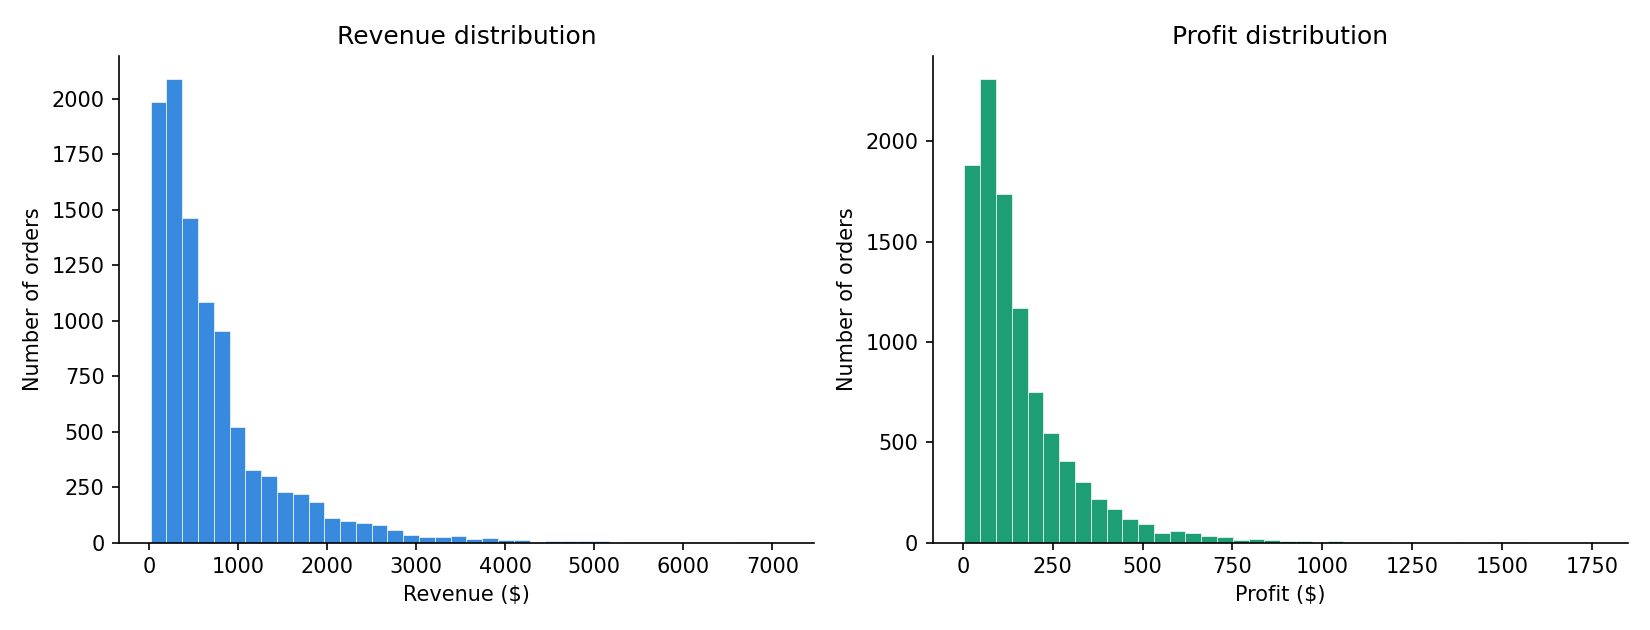

In [ ]:
from IPython.display import Image, display
display(Image('/content/eda_01_distributions.png'))

---




### 2. Profit Margin by Category

This bar chart illustrates the average profit margin across different product categories. 'Accessories' and 'Clothing & Apparel' show significantly higher margins compared to 'Home & Furniture' and 'Electronics'.

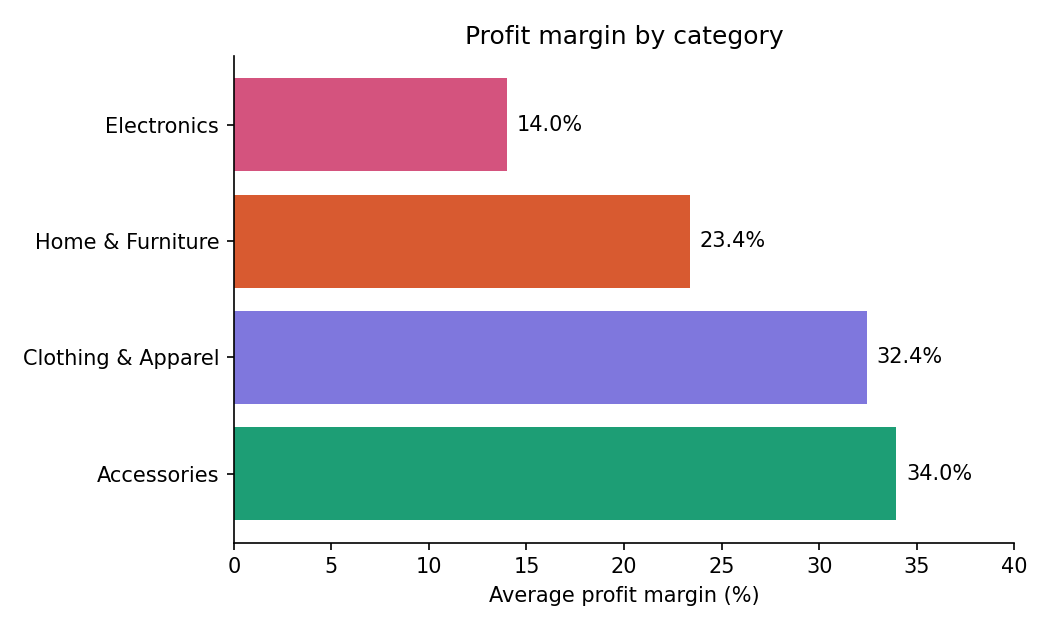

In [ ]:
from IPython.display import Image, display
display(Image('/content/eda_02_margin_by_category.png'))

---




### 3. Monthly Revenue and Profit Trend

This plot shows the total revenue and profit over time on a monthly basis. There are clear fluctuations, with a peak in November 2024 and a trough in February 2023, indicating potential seasonality or growth trends.

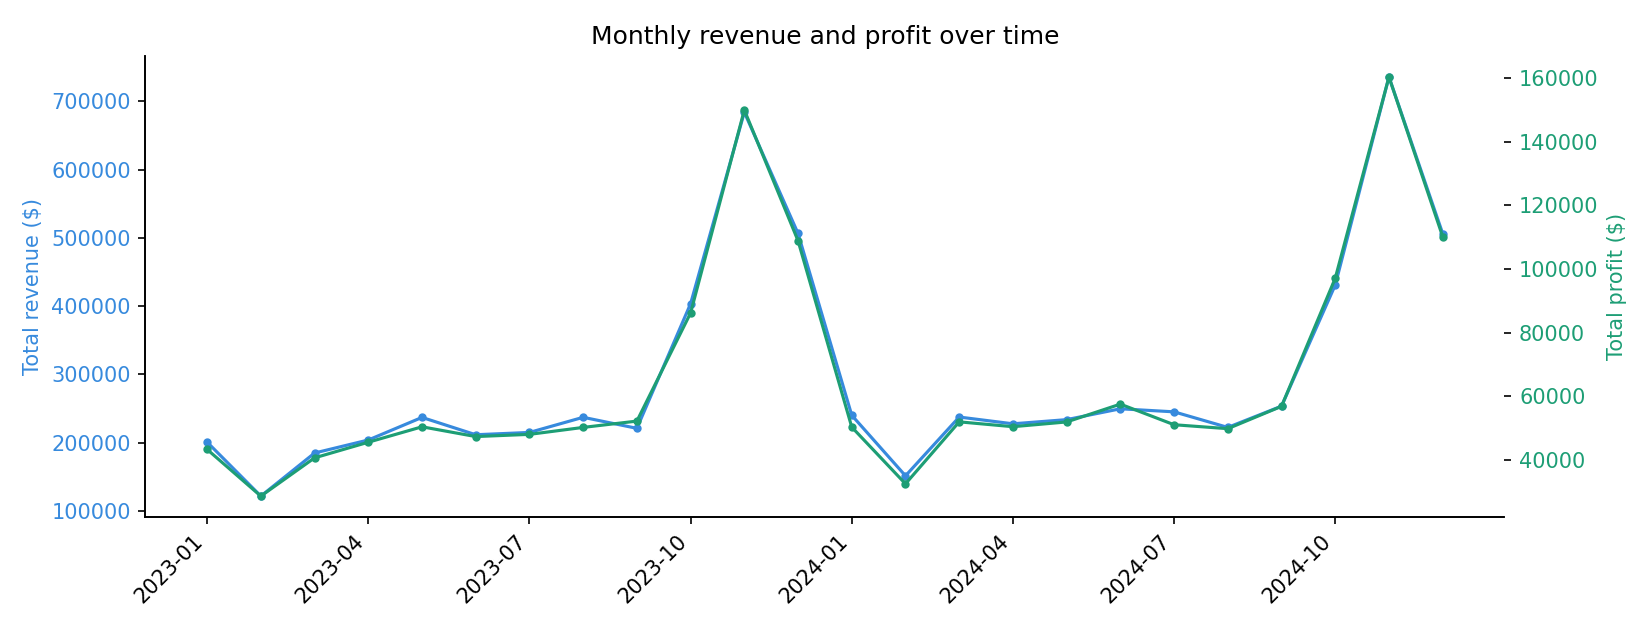

In [ ]:
from IPython.display import Image, display
display(Image('/content/eda_03_monthly_trend.png'))

---




### 4. Correlation Matrix and Revenue Formula Check

The correlation matrix visualizes the relationships between numeric features, while the scatter plot confirms that Revenue is a deterministic product of Quantity and Unit_Price.

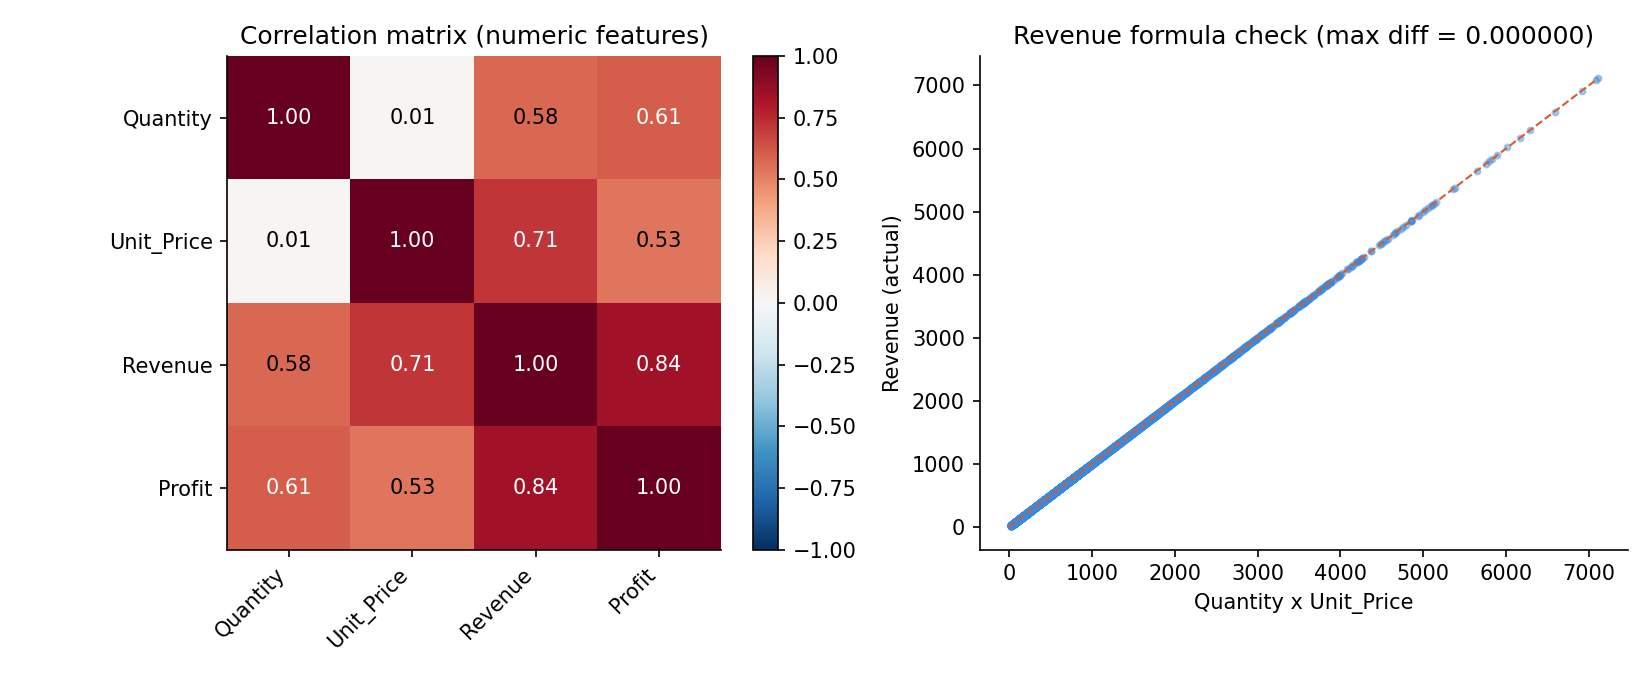

In [ ]:
from IPython.display import Image, display
display(Image('/content/eda_04_correlation_and_formula.png'))

Loaded 10000 rows spanning 2023-01-01 to 2024-12-31

Cutoff date: 2024-10-31
Train: 8317 rows (83.2%)  [2023-01-01 to 2024-10-31]
Test:  1683 rows (16.8%)  [2024-11-01 to 2024-12-31]

Category coverage check:
  Categories only in test (never seen in training): none
  Categories only in train (never scored in test):  none
  OK — model will not encounter unseen categories at test time.

Split integrity check: no overlap, correctly time-ordered. OK.

Saved -> step5_train.csv (8317 rows), step5_test.csv (1683 rows)


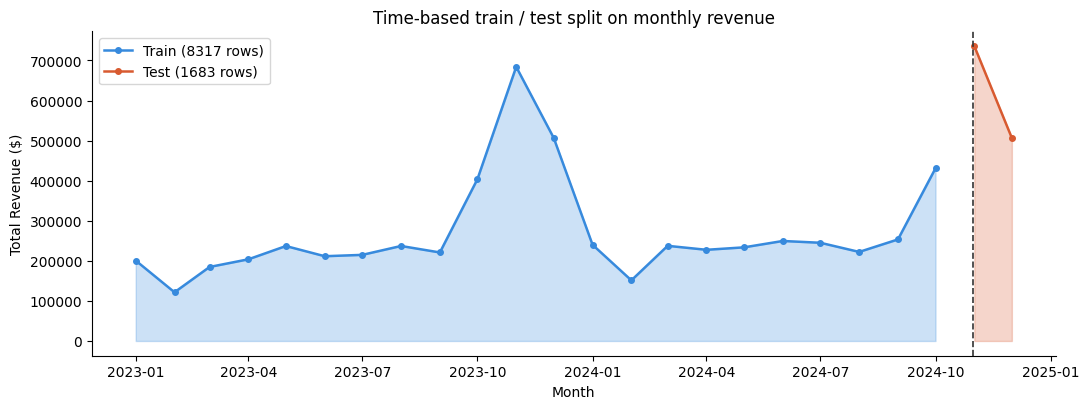

In [ ]:
"""
Step 5 — Train / Test Split
==============================
Goal: split the data so the test set genuinely represents "future,
unseen" orders — not a random shuffle that leaks seasonal patterns
from later months into training.

Approach: time-based split.
  Train: Jan 2023 -> Oct 2024   (~83% of rows)
  Test:  Nov 2024 -> Dec 2024   (~17% of rows, includes the seasonal peak)

A random split is deliberately avoided — it would let November/December
training rows inform predictions of November/December test rows from
other years, which is data leakage for a dataset with clear seasonality.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

OUT = "/content"

# ── Load Step 3's engineered data ──
df = pd.read_csv(f"{OUT}/step3_engineered.csv")
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df = df.sort_values("Order_Date").reset_index(drop=True)
print(f"Loaded {len(df)} rows spanning {df['Order_Date'].min().date()} "
      f"to {df['Order_Date'].max().date()}")

# ── Define the time-based cutoff ──
CUTOFF = pd.Timestamp("2024-10-31")

train = df[df["Order_Date"] <= CUTOFF].copy()
test = df[df["Order_Date"] > CUTOFF].copy()

print(f"\nCutoff date: {CUTOFF.date()}")
print(f"Train: {len(train)} rows ({len(train)/len(df):.1%})  "
      f"[{train['Order_Date'].min().date()} to {train['Order_Date'].max().date()}]")
print(f"Test:  {len(test)} rows ({len(test)/len(df):.1%})  "
      f"[{test['Order_Date'].min().date()} to {test['Order_Date'].max().date()}]")

# ── Validation 1: all categories present in both splits ──
train_cats = set(train["Category"].unique())
test_cats = set(test["Category"].unique())
missing_in_train = test_cats - train_cats
missing_in_test = train_cats - test_cats

print(f"\nCategory coverage check:")
print(f"  Categories only in test (never seen in training): {missing_in_train or 'none'}")
print(f"  Categories only in train (never scored in test):  {missing_in_test or 'none'}")
if missing_in_train:
    print("  WARNING: model will have never seen these categories during training.")
else:
    print("  OK — model will not encounter unseen categories at test time.")

# ── Validation 2: no accidental overlap or gap at the boundary ──
overlap = set(train.index) & set(test.index)
assert len(overlap) == 0, "Train/test indices overlap!"
assert train["Order_Date"].max() <= test["Order_Date"].min(), \
    "Train contains dates after test starts — split is not time-ordered!"
print("\nSplit integrity check: no overlap, correctly time-ordered. OK.")

# ── Visualize the split against the monthly trend ──
monthly = df.groupby(df["Order_Date"].dt.to_period("M"))["Revenue"].sum().reset_index()
monthly["Order_Date"] = monthly["Order_Date"].dt.to_timestamp()
train_m = monthly[monthly["Order_Date"] <= CUTOFF]
test_m = monthly[monthly["Order_Date"] > CUTOFF]

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.fill_between(train_m["Order_Date"], train_m["Revenue"], alpha=0.25, color="#378ADD")
ax.plot(train_m["Order_Date"], train_m["Revenue"], color="#378ADD", marker="o",
        markersize=4, linewidth=1.8, label=f"Train ({len(train)} rows)")
ax.fill_between(test_m["Order_Date"], test_m["Revenue"], alpha=0.25, color="#D85A30")
ax.plot(test_m["Order_Date"], test_m["Revenue"], color="#D85A30", marker="o",
        markersize=4, linewidth=1.8, label=f"Test ({len(test)} rows)")
ax.axvline(CUTOFF, color="#333", linewidth=1.2, linestyle="--")
ax.set_title("Time-based train / test split on monthly revenue")
ax.set_xlabel("Month"); ax.set_ylabel("Total Revenue ($)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/split_train_test.png", dpi=150)
#plt.close()

# ── Save the split for Step 6 onward ──
train.to_csv(f"{OUT}/step5_train.csv", index=False)
test.to_csv(f"{OUT}/step5_test.csv", index=False)
print(f"\nSaved -> step5_train.csv ({len(train)} rows), step5_test.csv ({len(test)} rows)")

In [ ]:
"""
Step 6 — Preprocessing Pipeline
==================================
Goal: transform train and test into numeric feature matrices, fitting
every encoder ONLY on train data, then applying it to test — this is
the single most important rule of this step, since fitting on the full
dataset before splitting is the most common source of data leakage.

Three preprocessing paths:
  1. One-hot encode low-cardinality categoricals   (Category, Region)
  2. One-hot encode higher-cardinality categoricals (Sub_Category, Product_Name)
  3. Pass numeric features through unscaled (fine for tree models;
     StandardScaler is added separately for linear models)
"""
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

#Piplines

OUT = "/content"

# ── Load Step 5's split ──
train = pd.read_csv(f"{OUT}/step5_train.csv")
test = pd.read_csv(f"{OUT}/step5_test.csv")
print(f"Train: {len(train)} rows  |  Test: {len(test)} rows")

# ── Column groups (from Steps 1 and 3) ──
CAT_LOW = ["Category", "Region"]                     # 4 values each
CAT_HIGH = ["Sub_Category", "Product_Name"]           # 19 and 49 values
NUM_REVENUE = ["Year", "Month", "Quarter"]             # Revenue model inputs
NUM_PROFIT = ["Quantity", "Unit_Price", "Revenue",     # Profit model inputs
              "Year", "Month", "Quarter"]

FEATURES_REVENUE = CAT_LOW + CAT_HIGH + NUM_REVENUE
FEATURES_PROFIT = CAT_LOW + CAT_HIGH + NUM_PROFIT

print(f"\nRevenue model inputs ({len(FEATURES_REVENUE)}): {FEATURES_REVENUE}")
print(f"Profit model inputs  ({len(FEATURES_PROFIT)}): {FEATURES_PROFIT}")


def build_preprocessor(num_cols: list[str], scale_numeric: bool = False) -> ColumnTransformer:
    """
    Build a ColumnTransformer that:
      - one-hot encodes CAT_LOW and CAT_HIGH separately (kept apart so
        each group's encoder can be inspected/swapped independently)
      - passes numeric columns through, or scales them if a linear
        model will consume the output
    handle_unknown='ignore' protects against a category appearing in
    test that the encoder never saw in train (defensive, even though
    Step 5 confirmed this doesn't happen here).
    """
    numeric_step = StandardScaler() if scale_numeric else "passthrough"
    return ColumnTransformer([
        ("ohe_low", OneHotEncoder(drop="first", handle_unknown="ignore",
                                   sparse_output=False), CAT_LOW),
        ("ohe_high", OneHotEncoder(drop="first", handle_unknown="ignore",
                                    sparse_output=False), CAT_HIGH),
        ("num", numeric_step, num_cols),
    ])


# ── Build and fit preprocessors — ONLY on training data ──
prep_revenue = build_preprocessor(NUM_REVENUE, scale_numeric=False)
prep_revenue.fit(train[FEATURES_REVENUE])

prep_profit = build_preprocessor(NUM_PROFIT, scale_numeric=False)
prep_profit.fit(train[FEATURES_PROFIT])

# ── Transform both train and test using the train-fitted encoders ──
X_train_rev = prep_revenue.transform(train[FEATURES_REVENUE])
X_test_rev = prep_revenue.transform(test[FEATURES_REVENUE])

X_train_prf = prep_profit.transform(train[FEATURES_PROFIT])
X_test_prf = prep_profit.transform(test[FEATURES_PROFIT])

print(f"\nRevenue feature matrix — train: {X_train_rev.shape}, test: {X_test_rev.shape}")
print(f"Profit feature matrix  — train: {X_train_prf.shape}, test: {X_test_prf.shape}")

# ── Recover feature names post-encoding (useful for importance later) ──
feat_names_rev = (
    list(prep_revenue.named_transformers_["ohe_low"].get_feature_names_out(CAT_LOW))
    + list(prep_revenue.named_transformers_["ohe_high"].get_feature_names_out(CAT_HIGH))
    + NUM_REVENUE
)
feat_names_prf = (
    list(prep_profit.named_transformers_["ohe_low"].get_feature_names_out(CAT_LOW))
    + list(prep_profit.named_transformers_["ohe_high"].get_feature_names_out(CAT_HIGH))
    + NUM_PROFIT
)
print(f"\nRevenue model — {len(feat_names_rev)} features after encoding")
print(f"Profit model  — {len(feat_names_prf)} features after encoding")

# ── Leak check: confirm encoders were fit only on train categories ──
# (handle_unknown='ignore' means unseen categories become all-zero rows
#  rather than raising an error — check none occurred here)
n_unknown_rev = (X_test_rev[:, :len(feat_names_rev) - len(NUM_REVENUE)].sum(axis=1) == 0).sum()
print(f"\nTest rows with an unseen category (Revenue model): {n_unknown_rev}")

# ── Save fitted preprocessors and transformed arrays for Step 7+ ──
joblib.dump(prep_revenue, f"{OUT}/step6_preprocessor_revenue.joblib")
joblib.dump(prep_profit, f"{OUT}/step6_preprocessor_profit.joblib")

np.save(f"{OUT}/step6_X_train_revenue.npy", X_train_rev)
np.save(f"{OUT}/step6_X_test_revenue.npy", X_test_rev)
np.save(f"{OUT}/step6_X_train_profit.npy", X_train_prf)
np.save(f"{OUT}/step6_X_test_profit.npy", X_test_prf)

print(f"\nSaved fitted preprocessors and transformed feature matrices to {OUT}/")

Train: 8317 rows  |  Test: 1683 rows

Revenue model inputs (7): ['Category', 'Region', 'Sub_Category', 'Product_Name', 'Year', 'Month', 'Quarter']
Profit model inputs  (10): ['Category', 'Region', 'Sub_Category', 'Product_Name', 'Quantity', 'Unit_Price', 'Revenue', 'Year', 'Month', 'Quarter']

Revenue feature matrix — train: (8317, 75), test: (1683, 75)
Profit feature matrix  — train: (8317, 78), test: (1683, 78)

Revenue model — 75 features after encoding
Profit model  — 78 features after encoding

Test rows with an unseen category (Revenue model): 0

Saved fitted preprocessors and transformed feature matrices to /content/


In [ ]:
"""
Step 7 — Baseline Model
=========================
Goal: establish the minimum bar every later model must beat.

Linear Regression is the baseline for both targets. Numeric features
are scaled here (unlike Step 6's tree-model pipeline) since linear
models are sensitive to feature scale — an unscaled Unit_Price
(0-7000) would dominate an unscaled Month (1-12) in the coefficients.
"""
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

OUT = "/content"

# ── Load Step 5's split ──
train = pd.read_csv(f"{OUT}/step5_train.csv")
test = pd.read_csv(f"{OUT}/step5_test.csv")

CAT_LOW = ["Category", "Region"]
CAT_HIGH = ["Sub_Category", "Product_Name"]
NUM_REVENUE = ["Year", "Month", "Quarter"]
NUM_PROFIT = ["Quantity", "Unit_Price", "Revenue", "Year", "Month", "Quarter"]

FEATURES_REVENUE = CAT_LOW + CAT_HIGH + NUM_REVENUE
FEATURES_PROFIT = CAT_LOW + CAT_HIGH + NUM_PROFIT


def build_baseline_pipeline(num_cols: list[str]) -> Pipeline:
    """
    Linear regression baseline. Numeric features are scaled here
    (scale_numeric=True equivalent) because linear regression's
    coefficients are directly affected by feature magnitude.
    """
    ct = ColumnTransformer([
        ("ohe_low", OneHotEncoder(drop="first", handle_unknown="ignore",
                                   sparse_output=False), CAT_LOW),
        ("ohe_high", OneHotEncoder(drop="first", handle_unknown="ignore",
                                    sparse_output=False), CAT_HIGH),
        ("num", StandardScaler(), num_cols),
    ])
    return Pipeline([("prep", ct), ("model", LinearRegression())])


def evaluate(y_true, y_pred, label: str) -> dict:
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    print(f"{label:8s} | R²={r2:.4f}  MAE=${mae:.2f}  RMSE=${rmse:.2f}")
    return {"r2": r2, "mae": mae, "rmse": rmse}


results = {}

# ── Revenue baseline ───
pipe_rev = build_baseline_pipeline(NUM_REVENUE)
pipe_rev.fit(train[FEATURES_REVENUE], train["Revenue"])
pred_rev = pipe_rev.predict(test[FEATURES_REVENUE])
results["revenue"] = evaluate(test["Revenue"], pred_rev, "REVENUE")

# ── Profit baseline ───
pipe_prf = build_baseline_pipeline(NUM_PROFIT)
pipe_prf.fit(train[FEATURES_PROFIT], train["Profit"])
pred_prf = pipe_prf.predict(test[FEATURES_PROFIT])
results["profit"] = evaluate(test["Profit"], pred_prf, "PROFIT")

# ── Sanity note on what these numbers mean ───
mean_revenue = test["Revenue"].mean()
mean_profit = test["Profit"].mean()
print(f"\nContext: mean test Revenue=${mean_revenue:.0f}, mean test Profit=${mean_profit:.0f}")
print(f"Revenue MAE is {results['revenue']['mae']/mean_revenue:.0%} of the mean value "
      f"-> {'weak' if results['revenue']['mae']/mean_revenue > 0.3 else 'reasonable'} baseline")
print(f"Profit MAE is {results['profit']['mae']/mean_profit:.0%} of the mean value "
      f"-> {'weak' if results['profit']['mae']/mean_profit > 0.3 else 'reasonable'} baseline")

# ── Save baseline models and predictions for later comparison ──
joblib.dump(pipe_rev, f"{OUT}/step7_baseline_revenue.joblib")
joblib.dump(pipe_prf, f"{OUT}/step7_baseline_profit.joblib")

pd.DataFrame({
    "actual_revenue": test["Revenue"].values, "pred_revenue": pred_rev,
    "actual_profit": test["Profit"].values, "pred_profit": pred_prf,
}).to_csv(f"{OUT}/step7_baseline_predictions.csv", index=False)

import json
with open(f"{OUT}/step7_baseline_scores.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"\nSaved baseline models, predictions, and scores to {OUT}/")

REVENUE  | R²=0.2636  MAE=$426.50  RMSE=$634.45
PROFIT   | R²=0.7948  MAE=$45.82  RMSE=$68.40

Context: mean test Revenue=$738, mean test Profit=$161
Revenue MAE is 58% of the mean value -> weak baseline
Profit MAE is 29% of the mean value -> reasonable baseline

Saved baseline models, predictions, and scores to /content/


In [ ]:
"""
Step 8 — Train Real Models
=============================
Goal: train non-linear models capable of learning interactions
(Category x Price x Month, etc.) that Linear Regression cannot capture,
and compare them honestly against the Step 7 baseline.

Two models per target:
  - Random Forest Regressor
  - XGBoost Regressor
"""
import pandas as pd
import numpy as np
import json
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from xgboost import XGBRegressor

OUT = "/content"

# ── Load Step 5's split ──
train = pd.read_csv(f"{OUT}/step5_train.csv")
test = pd.read_csv(f"{OUT}/step5_test.csv")

CAT_LOW = ["Category", "Region"]
CAT_HIGH = ["Sub_Category", "Product_Name"]
NUM_REVENUE = ["Year", "Month", "Quarter"]
NUM_PROFIT = ["Quantity", "Unit_Price", "Revenue", "Year", "Month", "Quarter"]

FEATURES_REVENUE = CAT_LOW + CAT_HIGH + NUM_REVENUE
FEATURES_PROFIT = CAT_LOW + CAT_HIGH + NUM_PROFIT


def build_tree_pipeline(num_cols: list[str], regressor) -> Pipeline:
    """Tree models don't need scaling — they split on thresholds,
    not distances, so raw numeric ranges don't distort them."""
    ct = ColumnTransformer([
        ("ohe_low", OneHotEncoder(drop="first", handle_unknown="ignore",
                                   sparse_output=False), CAT_LOW),
        ("ohe_high", OneHotEncoder(drop="first", handle_unknown="ignore",
                                    sparse_output=False), CAT_HIGH),
        ("num", "passthrough", num_cols),
    ])
    return Pipeline([("prep", ct), ("model", regressor)])


def evaluate(y_true, y_pred, label: str) -> dict:
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    print(f"{label:28s} | R²={r2:.4f}  MAE=${mae:.2f}  RMSE=${rmse:.2f}")
    return {"r2": r2, "mae": mae, "rmse": rmse}


# ── Model configs — same hyperparameters used across both targets ──
def make_rf():
    return RandomForestRegressor(
        n_estimators=300, max_depth=12, min_samples_leaf=5,
        random_state=42, n_jobs=-1,
    )

def make_xgb():
    return XGBRegressor(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0,
    )


results = {}
fitted_models = {}

for target_name, target_col, features, num_cols in [
    ("revenue", "Revenue", FEATURES_REVENUE, NUM_REVENUE),
    ("profit",  "Profit",  FEATURES_PROFIT,  NUM_PROFIT),
]:
    y_train = train[target_col]
    y_test = test[target_col]

    for model_name, make_model in [("random_forest", make_rf), ("xgboost", make_xgb)]:
        pipe = build_tree_pipeline(num_cols, make_model())
        pipe.fit(train[features], y_train)
        pred = pipe.predict(test[features])

        key = f"{target_name}_{model_name}"
        results[key] = evaluate(y_test, pred, f"{target_col:8s} {model_name}")
        fitted_models[key] = pipe

# ── Compare against Step 7 baseline ──
with open(f"{OUT}/step7_baseline_scores.json") as f:
    baseline = json.load(f)

print("\nModel comparison vs baseline:")
print(f"{'Target':10s} {'Model':16s} {'R²':>8s} {'MAE':>8s} {'vs baseline':>14s}")
for target_name, target_label in [("revenue", "Revenue"), ("profit", "Profit")]:
    base_r2 = baseline[target_name]["r2"]
    print(f"{target_label:10s} {'Linear (base)':16s} {base_r2:8.4f} "
          f"{baseline[target_name]['mae']:7.2f}$ {'—':>14s}")
    for model_name in ["random_forest", "xgboost"]:
        r2 = results[f"{target_name}_{model_name}"]["r2"]
        mae = results[f"{target_name}_{model_name}"]["mae"]
        delta = r2 - base_r2
        verdict = "better" if delta > 0 else "worse"
        print(f"{'':10s} {model_name:16s} {r2:8.4f} {mae:7.2f}$ "
              f"{delta:+.4f} ({verdict})")

# ── Identify the best model overall ──
best_key = max(results, key=lambda k: results[k]["r2"])
print(f"\nBest model: {best_key}  (R²={results[best_key]['r2']:.4f})")

# ── Save everything for Step 9+ ───
for key, model in fitted_models.items():
    joblib.dump(model, f"{OUT}/step8_model_{key}.joblib")

with open(f"{OUT}/step8_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"\nSaved {len(fitted_models)} fitted models and results to {OUT}/")

Revenue  random_forest       | R²=0.2142  MAE=$438.60  RMSE=$655.40
Revenue  xgboost             | R²=0.1403  MAE=$451.16  RMSE=$685.51
Profit   random_forest       | R²=0.8597  MAE=$36.35  RMSE=$56.55
Profit   xgboost             | R²=0.8550  MAE=$36.43  RMSE=$57.49

Model comparison vs baseline:
Target     Model                  R²      MAE    vs baseline
Revenue    Linear (base)      0.2636  426.50$              —
           random_forest      0.2142  438.60$ -0.0494 (worse)
           xgboost            0.1403  451.16$ -0.1233 (worse)
Profit     Linear (base)      0.7948   45.82$              —
           random_forest      0.8597   36.35$ +0.0650 (better)
           xgboost            0.8550   36.43$ +0.0602 (better)

Best model: profit_random_forest  (R²=0.8597)

Saved 4 fitted models and results to /content/


In [ ]:
"""
Step 9 — Evaluate Models

Goal: go beyond a single R² number to understand WHERE and HOW BADLY
the model is wrong, and whether that error is acceptable for the
business use case.

Metrics computed, and what each answers:
  R²      - what fraction of target variance is explained
  MAE     - average dollar error per prediction
  RMSE    - dollar error, penalising large misses more heavily
  MAPE    - average error as a percentage of the actual value
  Bias    - is the model systematically over- or under-predicting
  Within-tolerance - % of predictions "close enough" to be useful
"""

import pandas as pd
import numpy as np
import joblib
import json

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

OUT = "/content"

# ── Load Step 5's test split and Step 8's results to find best model ───
train = pd.read_csv(f"{OUT}/step5_train.csv")
test = pd.read_csv(f"{OUT}/step5_test.csv")

with open(f"{OUT}/step8_results.json") as f:
    step8_results = json.load(f)

best_key = max(step8_results, key=lambda k: step8_results[k]["r2"])
target_name, model_name = best_key.rsplit("_", 1) if "random_forest" not in best_key else \
    (best_key.replace("_random_forest", ""), "random_forest")
# handle xgboost/random_forest naming cleanly
if best_key.endswith("random_forest"):
    target_name = best_key.replace("_random_forest", "")
    model_name = "random_forest"
elif best_key.endswith("xgboost"):
    target_name = best_key.replace("_xgboost", "")
    model_name = "xgboost"

target_col = "Revenue" if target_name == "revenue" else "Profit"
print(f"Evaluating best model from Step 8: {best_key}  (target={target_col})")

# ── Load the fitted pipeline directly — no retraining ───
pipe = joblib.load(f"{OUT}/step8_model_{best_key}.joblib")

CAT_LOW = ["Category", "Region"]
CAT_HIGH = ["Sub_Category", "Product_Name"]
NUM_REVENUE = ["Year", "Month", "Quarter"]
NUM_PROFIT = ["Quantity", "Unit_Price", "Revenue", "Year", "Month", "Quarter"]
features = CAT_LOW + CAT_HIGH + (NUM_REVENUE if target_name == "revenue" else NUM_PROFIT)

y_true = test[target_col].values
y_pred = pipe.predict(test[features])

# ── Core metrics ───
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
bias = float(np.mean(y_pred - y_true))

# ── MAPE (guard against divide-by-zero on any zero-value orders) ───
mask = y_true > 0
mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

# ── Within-tolerance: % of predictions within X% of actual ───
def within_pct(actual, pred, pct):
    return float(np.mean(np.abs(pred - actual) / np.maximum(actual, 1) <= pct) * 100)

tolerance_bands = {f"within_{int(p*100)}pct": within_pct(y_true, y_pred, p)
                    for p in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]}

# ── Residual percentiles ──
residuals = y_pred - y_true
percentiles = {f"p{p}": float(np.percentile(residuals, p)) for p in [5, 25, 50, 75, 95]}

print(f"\n{target_col.upper()} — {model_name}")
print(f"  R²={r2:.4f}  MAE=${mae:.2f}  RMSE=${rmse:.2f}")
print(f"  MAPE={mape:.2f}%  Bias=${bias:.2f}")
print(f"  Within 10%: {tolerance_bands['within_10pct']:.1f}%  |  "
      f"Within 25%: {tolerance_bands['within_25pct']:.1f}%")
print(f"  Residual percentiles: {percentiles}")

# ── Error breakdown by Category — where is the model weakest? ──
cat_test = test["Category"].values
print(f"\nMAE by Category:")
cat_mae = {}
for cat in sorted(set(cat_test)):
    m = np.mean(np.abs(y_pred[cat_test == cat] - y_true[cat_test == cat]))
    cat_mae[cat] = float(m)
    print(f"  {cat:<20} ${m:.2f}")

# ── Save full evaluation report ───
eval_report = {
    "best_model": best_key,
    "target": target_col,
    "r2": r2, "mae": mae, "rmse": rmse, "mape": mape, "bias": bias,
    "tolerance_bands": tolerance_bands,
    "residual_percentiles": percentiles,
    "mae_by_category": cat_mae,
}
with open(f"{OUT}/step9_evaluation_report.json", "w") as f:
    json.dump(eval_report, f, indent=2)

pd.DataFrame({"actual": y_true, "predicted": y_pred, "category": cat_test}) \
    .to_csv(f"{OUT}/step9_predictions.csv", index=False)

print(f"\nSaved evaluation report -> step9_evaluation_report.json")
print(f"Saved predictions       -> step9_predictions.csv")

Evaluating best model from Step 8: profit_random_forest  (target=Profit)

PROFIT — random_forest
  R²=0.8597  MAE=$36.35  RMSE=$56.55
  MAPE=24.86%  Bias=$1.58
  Within 10%: 23.5%  |  Within 25%: 59.8%
  Residual percentiles: {'p5': -79.97518538891818, 'p25': -22.347048118063107, 'p50': -0.35630163083077804, 'p75': 22.203853655026997, 'p95': 87.83628003454437}

MAE by Category:
  Accessories          $22.69
  Clothing & Apparel   $27.59
  Electronics          $36.06
  Home & Furniture     $56.50

Saved evaluation report -> step9_evaluation_report.json
Saved predictions       -> step9_predictions.csv


In [ ]:
"""
Step 10 — Cross-Validation and Hyperparameter Tuning
=======================================================
Goal: get a reliable, non-lucky performance estimate via cross-validation,
then search for better hyperparameters than the defaults used in Step 8.

TimeSeriesSplit (not standard k-fold) is used throughout — it always
keeps validation folds strictly LATER in time than their training
fold, matching how the model will actually be used (predicting the
future from the past), and avoiding the leakage a random k-fold would
introduce given this dataset's clear seasonality.

RandomizedSearchCV (not GridSearchCV) is used because the full grid
here is ~2,400 combinations x 5 folds = 12,000 fits — far too slow.
Random sampling of 30 combinations finds nearly as good a result in
a fraction of the time, because hyperparameter landscapes are smooth.
"""
import pandas as pd
import numpy as np
import json
import joblib
import warnings
import time
import os
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

OUT = "/content"

# ── Load Step 5's split ───
train_path = f"{OUT}/step5_train.csv"
test_path = f"{OUT}/step5_test.csv"

if not os.path.exists(train_path):
    raise FileNotFoundError(
        f"Missing {train_path}. Please ensure Step 5 (cell g2m1A6_4wx-T) "
        "has been successfully executed to create the train/test split files."
    )
if not os.path.exists(test_path):
    raise FileNotFoundError(
        f"Missing {test_path}. Please ensure Step 5 (cell g2m1A6_4wx-T) "
        "has been successfully executed to create the train/test split files."
    )

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

# Step 9 identified profit_random_forest as the best model — tune that one
CAT_LOW = ["Category", "Region"]
CAT_HIGH = ["Sub_Category", "Product_Name"]
NUM_PROFIT = ["Quantity", "Unit_Price", "Revenue", "Year", "Month", "Quarter"]
FEATURES_PROFIT = CAT_LOW + CAT_HIGH + NUM_PROFIT

X_train = train[FEATURES_PROFIT]
y_train = train["Profit"]
X_test = test[FEATURES_PROFIT]
y_test = test["Profit"]

def make_ct():
    return ColumnTransformer([
        ("ohe_low", OneHotEncoder(drop="first", handle_unknown="ignore",
                                   sparse_output=False), CAT_LOW),
        ("ohe_high", OneHotEncoder(drop="first", handle_unknown="ignore",
                                    sparse_output=False), CAT_HIGH),
        ("num", "passthrough", NUM_PROFIT),
    ])

# ── Step 10a: cross-validation BEFORE tuning (sanity baseline) ───
tscv = TimeSeriesSplit(n_splits=5)

base_pipe = Pipeline([
    ("prep", make_ct()),
    ("model", RandomForestRegressor(n_estimators=300, max_depth=12,
                                     min_samples_leaf=5, random_state=42, n_jobs=-1)),
])

cv_scores = cross_val_score(base_pipe, X_train, y_train, cv=tscv, scoring="r2", n_jobs=-1)
print(f"CV before tuning — fold R²: {np.round(cv_scores, 4).tolist()}")
print(f"Mean={cv_scores.mean():.4f}  Std={cv_scores.std():.4f}")

# ── Step 10b: RandomizedSearchCV ───
param_dist = {
    "model__n_estimators": [100, 200, 300, 400, 500],
    "model__max_depth": [6, 8, 10, 12, 15, None],
    "model__min_samples_leaf": [2, 3, 5, 8, 10],
    "model__max_features": ["sqrt", "log2", 0.5, 0.7],
    "model__min_samples_split": [2, 4, 6, 10],
}

search_pipe = Pipeline([
    ("prep", make_ct()),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

search = RandomizedSearchCV(
    search_pipe, param_dist,
    n_iter=30, cv=tscv, scoring="r2",
    random_state=42, n_jobs=-1, verbose=0,
)

t0 = time.time()
search.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"\nRandomizedSearchCV done in {elapsed:.1f}s over 30 iterations")
print(f"Best CV R²: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

# ── Step 10c: evaluate the tuned model on the held-out test set ───
best_model = search.best_estimator_
pred_tuned = best_model.predict(X_test)

r2_tuned = r2_score(y_test, pred_tuned)
mae_tuned = mean_absolute_error(y_test, pred_tuned)
rmse_tuned = root_mean_squared_error(y_test, pred_tuned)

print(f"\nTuned model on held-out test:")
print(f"  R²={r2_tuned:.4f}  MAE=${mae_tuned:.2f}  RMSE=${rmse_tuned:.2f}")

# ── Compare before vs after tuning ───
with open(f"{OUT}/step8_results.json") as f:
    step8_results = json.load(f)
before = step8_results["profit_random_forest"]

print(f"\nBefore vs after tuning:")
print(f"  R²:   {before['r2']:.4f} -> {r2_tuned:.4f}  (Δ={r2_tuned-before['r2']:+.4f})")
print(f"  MAE:  ${before['mae']:.2f} -> ${mae_tuned:.2f}  (Δ=${mae_tuned-before['mae']:+.2f})")
print(f"  RMSE: ${before['rmse']:.2f} -> ${rmse_tuned:.2f}  (Δ=${rmse_tuned-before['rmse']:+.2f})")

# ── Decide whether tuning was worth keeping ───
if r2_tuned >= before["r2"]:
    print("\nTuned model KEPT — matches or beats the Step 8 default model.")
    joblib.dump(best_model, f"{OUT}/step10_tuned_model.joblib")
else:
    print("\nTuned model DISCARDED — Step 8 default model performs better; keeping that one.")
    joblib.dump(joblib.load(f"{OUT}/step8_model_profit_random_forest.joblib"),
                f"{OUT}/step10_tuned_model.joblib")

# ── Save results ───
tuning_report = {
    "cv_scores_before_tuning": cv_scores.tolist(),
    "cv_mean_before": float(cv_scores.mean()),
    "cv_std_before": float(cv_scores.std()),
    "best_cv_score_after_search": float(search.best_score_),
    "best_params": search.best_params_,
    "test_r2_before": before["r2"], "test_r2_after": r2_tuned,
    "test_mae_before": before["mae"], "test_mae_after": mae_tuned,
    "test_rmse_before": before["rmse"], "test_rmse_after": rmse_tuned,
}
with open(f"{OUT}/step10_tuning_report.json", "w") as f:
    json.dump(tuning_report, f, indent=2)

print(f"\nSaved tuned model and tuning report to {OUT}/")

CV before tuning — fold R²: [0.8328, 0.84, 0.8295, 0.8625, 0.8697]
Mean=0.8469  Std=0.0162

RandomizedSearchCV done in 298.3s over 30 iterations
Best CV R²: 0.8479
Best params: {'model__n_estimators': 100, 'model__min_samples_split': 6, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 10}

Tuned model on held-out test:
  R²=0.8596  MAE=$36.30  RMSE=$56.57

Before vs after tuning:
  R²:   0.8597 -> 0.8596  (Δ=-0.0001)
  MAE:  $36.35 -> $36.30  (Δ=$-0.05)
  RMSE: $56.55 -> $56.57  (Δ=$+0.02)

Tuned model DISCARDED — Step 8 default model performs better; keeping that one.

Saved tuned model and tuning report to /content/


In [ ]:
"""
Step 11 — Feature Importance and Interpretation

Goal: explain WHICH features drive Profit predictions, and BY HOW MUCH,
in a way that's both technically sound and business-readable.

Two importance methods, and why both are computed:
  - Built-in RF importance: fast, but biased toward high-cardinality
    and continuous features (it counts how often a feature is split on,
    not its true dollar impact).
  - SHAP: slower, but unbiased — measures the actual average impact
    of each feature on individual predictions, and can explain any
    single prediction, not just the model globally.
"""

import pandas as pd
import numpy as np
import json
import joblib
import warnings
warnings.filterwarnings("ignore")
import shap

OUT = "/content"

# ── Load Step 5's split and Step 10's final model ───
train = pd.read_csv(f"{OUT}/step5_train.csv")
test = pd.read_csv(f"{OUT}/step5_test.csv")

pipe = joblib.load(f"{OUT}/step10_tuned_model.joblib")

CAT_LOW = ["Category", "Region"]
CAT_HIGH = ["Sub_Category", "Product_Name"]
NUM_PROFIT = ["Quantity", "Unit_Price", "Revenue", "Year", "Month", "Quarter"]
FEATURES_PROFIT = CAT_LOW + CAT_HIGH + NUM_PROFIT

y_test = test["Profit"].values

# ── Recover feature names after encoding ───
prep = pipe.named_steps["prep"]
ohe_low_names = prep.named_transformers_["ohe_low"].get_feature_names_out(CAT_LOW).tolist()
ohe_high_names = prep.named_transformers_["ohe_high"].get_feature_names_out(CAT_HIGH).tolist()
all_feature_names = ohe_low_names + ohe_high_names + NUM_PROFIT

# ── Method 1: built-in Random Forest importance ───
model = pipe.named_steps["model"]
rf_importances = model.feature_importances_

feat_imp_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_importances,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Top 10 features — Random Forest built-in importance:")
print(feat_imp_df.head(10).to_string(index=False))

# ── Method 2: SHAP values on the test set ───
X_test_transformed = prep.transform(test[FEATURES_PROFIT])
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    "feature": all_feature_names,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\nTop 10 features — SHAP mean |impact| on Profit prediction ($):")
print(shap_df.head(10).to_string(index=False))

# ── Category-level effect: sum SHAP across all Category dummy columns ──
cat_cols_idx = [i for i, f in enumerate(all_feature_names) if f.startswith("Category")]
cat_shap_total = shap_values[:, cat_cols_idx].sum(axis=1)

cat_test_values = test["Category"].values
print("\nAverage Category effect on Profit prediction (summed SHAP, $):")
category_effect = {}
for cat in sorted(set(cat_test_values)):
    avg_effect = float(cat_shap_total[cat_test_values == cat].mean())
    category_effect[cat] = avg_effect
    direction = "pushes UP" if avg_effect > 0 else "pushes DOWN"
    print(f"  {cat:<20} {avg_effect:+7.2f}  ({direction} predicted Profit)")

# ── Explain a single prediction (the largest-profit test order) ───
idx = int(np.argmax(y_test))
example_shap = shap_values[idx]
top_contributors_idx = np.argsort(np.abs(example_shap))[::-1][:5]

print(f"\nExample — largest-profit order in test set (actual=${y_test[idx]:.0f}):")
print(f"  Model prediction: ${model.predict(X_test_transformed[idx:idx+1])[0]:.0f}")
print(f"  Top 5 contributing features:")
for i in top_contributors_idx:
    sign = "+" if example_shap[i] > 0 else ""
    print(f"    {all_feature_names[i]:<25} {sign}{example_shap[i]:.2f}")

# ── Save everything ───
feat_imp_df.to_csv(f"{OUT}/step11_rf_importance.csv", index=False)
shap_df.to_csv(f"{OUT}/step11_shap_importance.csv", index=False)

np.save(f"{OUT}/step11_shap_values.npy", shap_values)

summary = {
    "top_5_rf_importance": feat_imp_df.head(5).to_dict("records"),
    "top_5_shap_importance": shap_df.head(5).to_dict("records"),
    "category_effect_on_profit": category_effect,
}
with open(f"{OUT}/step11_feature_importance_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"\nSaved feature importance tables, SHAP values, and summary to {OUT}/")

Top 10 features — Random Forest built-in importance:
                  feature  importance
                  Revenue    0.831047
     Category_Electronics    0.102605
Category_Home & Furniture    0.020005
               Unit_Price    0.017138
                    Month    0.008840
                     Year    0.002606
              Region_East    0.002203
                 Quantity    0.002099
                  Quarter    0.001846
              Region_West    0.001411

Top 10 features — SHAP mean |impact| on Profit prediction ($):
                    feature  mean_abs_shap
                    Revenue     106.043983
       Category_Electronics      39.846031
  Category_Home & Furniture      13.764477
                 Unit_Price       2.259231
                      Month       1.194330
                       Year       0.853364
                Region_East       0.480199
Category_Clothing & Apparel       0.389765
                Region_West       0.308882
                   Quantity       0